In [7]:
# Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [8]:
# Load Data

df = pd.read_csv("../data/bread basket.csv")
df.columns = df.columns.str.strip()
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend
8,5,Pastry,30-10-2016 10:13,morning,weekend
9,5,Bread,30-10-2016 10:13,morning,weekend


In [9]:
for cols in df.columns:
    print(df[cols].unique(), end="\n")

jumlah_none = len(df[df['Item'] == 'NONE'])
print(f"Jumlah None: {jumlah_none}")

[   1    2    3 ... 9682 9683 9684]
['Bread' 'Scandinavian' 'Hot chocolate' 'Jam' 'Cookies' 'Muffin' 'Coffee'
 'Pastry' 'Medialuna' 'Tea' 'Tartine' 'Basket' 'Mineral water'
 'Farm House' 'Fudge' 'Juice' "Ella's Kitchen Pouches" 'Victorian Sponge'
 'Frittata' 'Hearty & Seasonal' 'Soup' 'Pick and Mix Bowls' 'Smoothies'
 'Cake' 'Mighty Protein' 'Chicken sand' 'Coke' 'My-5 Fruit Shoot'
 'Focaccia' 'Sandwich' 'Alfajores' 'Eggs' 'Brownie' 'Dulce de Leche'
 'Honey' 'The BART' 'Granola' 'Fairy Doors' 'Empanadas' 'Keeping It Local'
 'Art Tray' 'Bowl Nic Pitt' 'Bread Pudding' 'Adjustment' 'Truffles'
 'Chimichurri Oil' 'Bacon' 'Spread' 'Kids biscuit' 'Siblings'
 'Caramel bites' 'Jammie Dodgers' 'Tiffin' 'Olum & polenta' 'Polenta'
 'The Nomad' 'Hack the stack' 'Bakewell' 'Lemon and coconut' 'Toast'
 'Scone' 'Crepes' 'Vegan mincepie' 'Bare Popcorn' 'Muesli' 'Crisps'
 'Pintxos' 'Gingerbread syrup' 'Panatone' 'Brioche and salami'
 'Afternoon with the baker' 'Salad' 'Chicken Stew' 'Spanish Brunch'
 'R

In [10]:
if 'Item' in df.columns:
    df = df[df['Item'] != 'NONE']
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend
5,3,Cookies,30-10-2016 10:07,morning,weekend
6,4,Muffin,30-10-2016 10:08,morning,weekend
7,5,Coffee,30-10-2016 10:13,morning,weekend
8,5,Pastry,30-10-2016 10:13,morning,weekend
9,5,Bread,30-10-2016 10:13,morning,weekend


In [11]:
# EDA (Exploratory Data Analysis)

sns.set_theme(style="whitegrid")

C:\Users\leona\AppData\Local\Temp\ipykernel_20340\858107045.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')


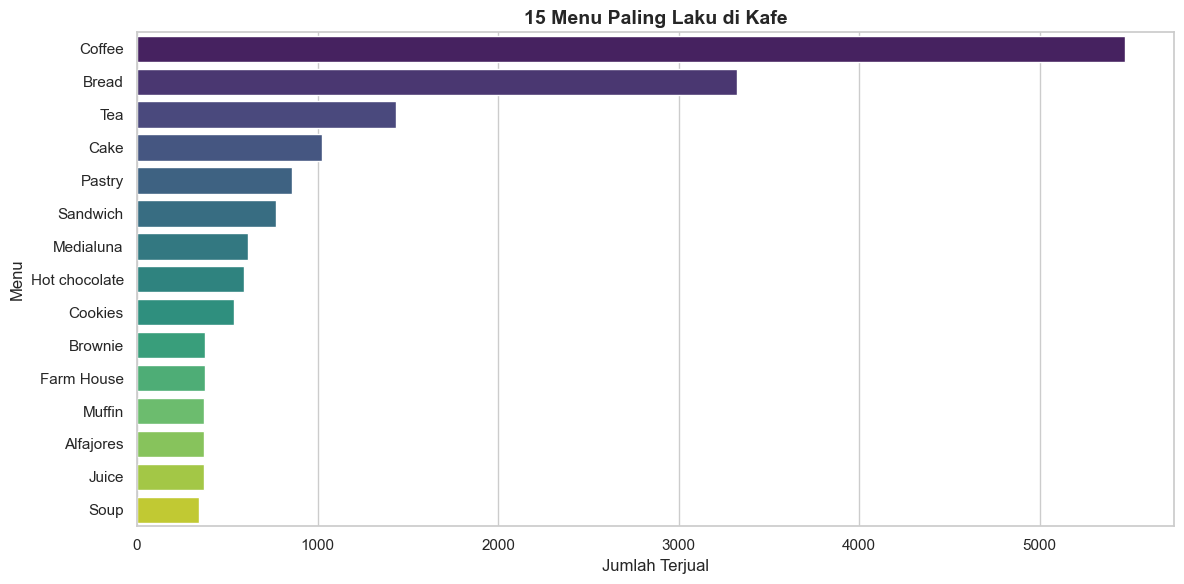

In [12]:
# 1. 15 Menu Paling Laku
plt.figure(figsize=(12, 6))
top_items = df['Item'].value_counts().head(15)
sns.barplot(x=top_items.values, y=top_items.index, palette='viridis')
plt.title('15 Menu Paling Laku di Kafe', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Terjual')
plt.ylabel('Menu')
plt.tight_layout()
plt.show()

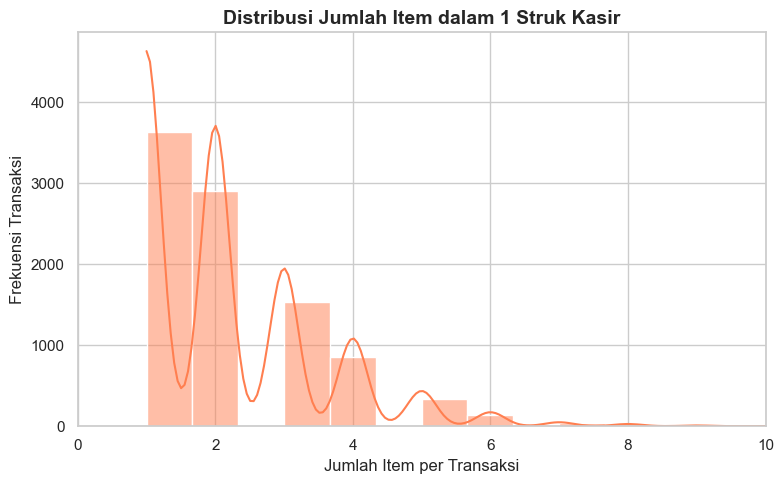

In [18]:
# 2. Distribusi Jumlah Item per Transaksi
plt.figure(figsize=(8, 5))
items_per_transaction = df.groupby('Transaction')['Item'].count()
# Kita batasi sumbu x sampai 10 agar grafiknya tidak rusak karena outlier (orang yang beli terlalu banyak)
sns.histplot(items_per_transaction, bins=15, kde=True, color='coral')
plt.title('Distribusi Jumlah Item dalam 1 Struk Kasir', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Item per Transaksi')
plt.ylabel('Frekuensi Transaksi')
plt.xlim(0, 10) 
plt.tight_layout()
plt.show()

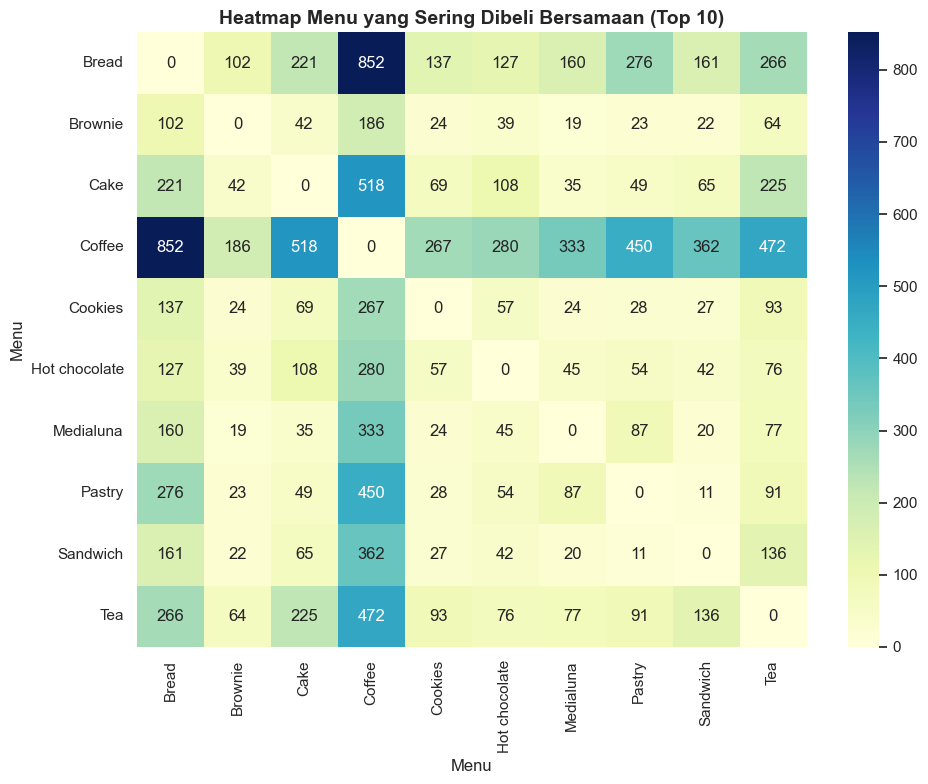

In [13]:
# 3. Heatmap Co-Occurence
top_10_items = df['Item'].value_counts().head(10).index
df_top = df[df['Item'].isin(top_10_items)]

plt.figure(figsize=(10, 8))
# Membangun matriks berdasarkan Transaction (Struk Kasir), BUKAN CustomerName lagi
item_transaction_matrix = pd.crosstab(df_top['Item'], df_top['Transaction']).clip(upper=1)
co_occurrence = item_transaction_matrix.dot(item_transaction_matrix.T)
np.fill_diagonal(co_occurrence.values, 0)

sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlGnBu")
plt.title('Heatmap Menu yang Sering Dibeli Bersamaan (Top 10)', fontsize=14, fontweight='bold')
plt.xlabel('Menu')
plt.ylabel('Menu')
plt.tight_layout()
plt.show()

# 4. Sparsity Analysis
Seberapa "kosong" item-transaction matrix — angka sparsity tinggi (mendekati 1.0) artinya user/transaksi hanya membeli sebagian kecil dari semua item yang ada. Ini sangat kritis untuk memilih algoritma Recommender System.

In [14]:
# 4. Sparsity Analysis
all_items = df['Item'].unique()
all_transactions = df['Transaction'].unique()

item_transaction_matrix_full = pd.crosstab(df['Transaction'], df['Item']).clip(upper=1)
total_cells = item_transaction_matrix_full.shape[0] * item_transaction_matrix_full.shape[1]
filled_cells = item_transaction_matrix_full.values.sum()
sparsity = 1 - (filled_cells / total_cells)

print(f"Jumlah Transaksi Unik : {len(all_transactions)}")
print(f"Jumlah Item Unik      : {len(all_items)}")
print(f"Ukuran Matrix         : {item_transaction_matrix_full.shape[0]} x {item_transaction_matrix_full.shape[1]}")
print(f"Total Sel Terisi      : {filled_cells}")
print(f"Sparsity              : {sparsity:.4%}")
print()
print("Interpretasi: Semakin tinggi sparsity, semakin cocok pakai model seperti")
print("Implicit Feedback Collaborative Filtering atau Association Rules (Apriori/FP-Growth).")

Jumlah Transaksi Unik : 9465
Jumlah Item Unik      : 94
Ukuran Matrix         : 9465 x 94
Total Sel Terisi      : 18887
Sparsity              : 97.8772%

Interpretasi: Semakin tinggi sparsity, semakin cocok pakai model seperti
Implicit Feedback Collaborative Filtering atau Association Rules (Apriori/FP-Growth).


# 5. Long Tail Distribution (Item Popularity)
Dalam Recommender System, biasanya ada "head items" (sedikit item yang sangat populer) dan "long tail" (banyak item yang jarang dibeli). Visualisasi ini penting untuk memahami tantangan cold-start dan coverage rekomendasi.

Top 20% item (18 item) menyumbang 86.6% dari total transaksi
Sisa 80% item (76 item) hanya 13.4% dari total transaksi


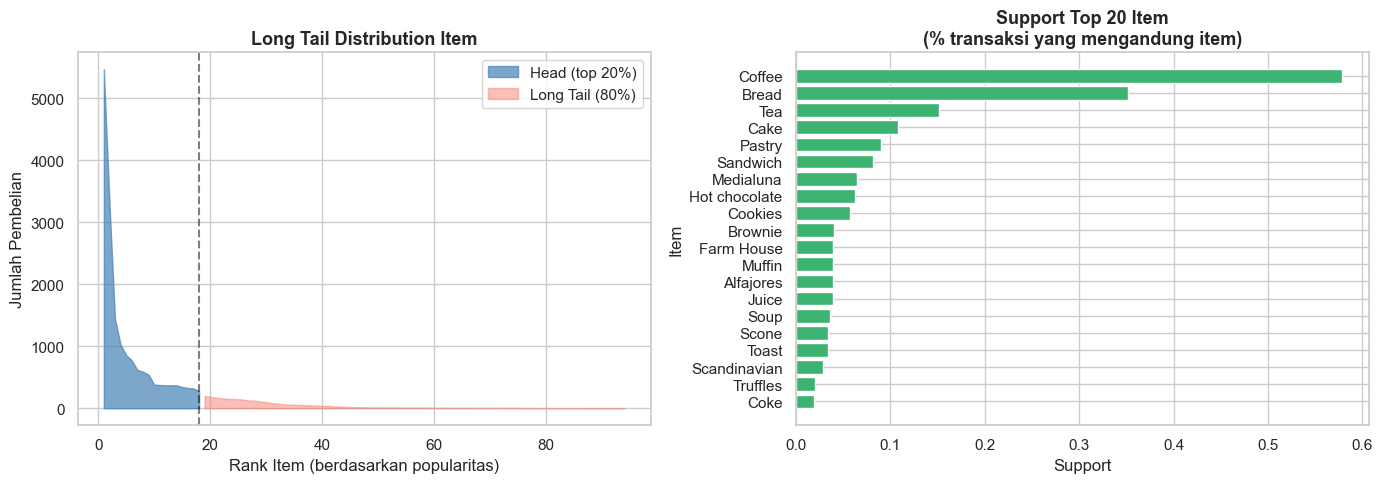

In [15]:
# 5. Long Tail Distribution
item_counts = df['Item'].value_counts().reset_index()
item_counts.columns = ['Item', 'Count']
item_counts['Rank'] = range(1, len(item_counts) + 1)

# Tentukan threshold: top 20% item
top_20_pct_idx = int(len(item_counts) * 0.2)
head_count = item_counts['Count'][:top_20_pct_idx].sum()
tail_count = item_counts['Count'][top_20_pct_idx:].sum()
total_count = item_counts['Count'].sum()

print(f"Top 20% item ({top_20_pct_idx} item) menyumbang {head_count/total_count:.1%} dari total transaksi")
print(f"Sisa 80% item ({len(item_counts)-top_20_pct_idx} item) hanya {tail_count/total_count:.1%} dari total transaksi")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: Long Tail plot
axes[0].fill_between(item_counts['Rank'][:top_20_pct_idx], item_counts['Count'][:top_20_pct_idx],
                     alpha=0.7, color='steelblue', label=f'Head (top 20%)')
axes[0].fill_between(item_counts['Rank'][top_20_pct_idx:], item_counts['Count'][top_20_pct_idx:],
                     alpha=0.5, color='salmon', label=f'Long Tail (80%)')
axes[0].set_title('Long Tail Distribution Item', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rank Item (berdasarkan popularitas)')
axes[0].set_ylabel('Jumlah Pembelian')
axes[0].legend()
axes[0].axvline(x=top_20_pct_idx, color='black', linestyle='--', alpha=0.5)

# Kanan: Support per item (bar top 20)
top20 = item_counts.head(20).copy()
top20['Support'] = top20['Count'] / df['Transaction'].nunique()
axes[1].barh(top20['Item'][::-1], top20['Support'][::-1], color='mediumseagreen')
axes[1].set_title('Support Top 20 Item\n(% transaksi yang mengandung item)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Item')

plt.tight_layout()
plt.show()

# 6. Top Item Pairs (Association Rules Preview)
Menampilkan pasangan item yang paling sering dibeli bersamaan dalam 1 transaksi. Ini adalah dasar dari algoritma Association Rules (Apriori/FP-Growth) untuk Recommender System berbasis "frequently bought together".

C:\Users\leona\AppData\Local\Temp\ipykernel_20340\4233367089.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Pair_Label', data=top_pairs, palette='magma')


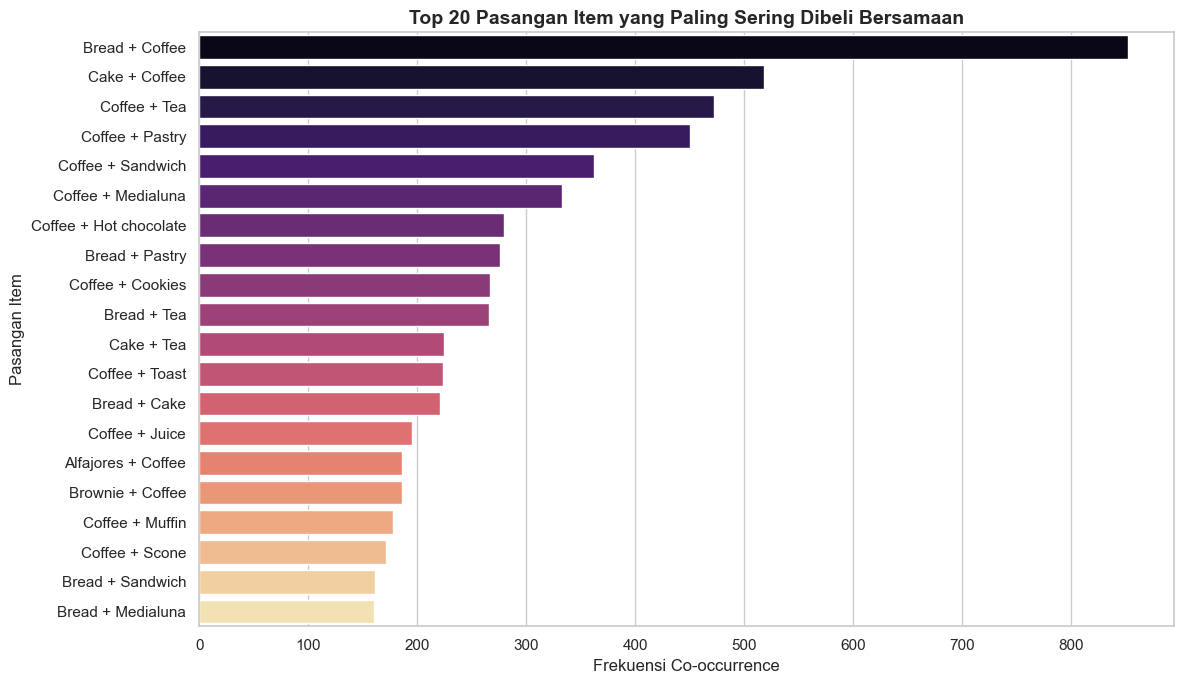


Top 10 pasangan dengan Support:
            Pair_Label  Count  Support
        Bread + Coffee    852 0.090016
         Cake + Coffee    518 0.054728
          Coffee + Tea    472 0.049868
       Coffee + Pastry    450 0.047544
     Coffee + Sandwich    362 0.038246
    Coffee + Medialuna    333 0.035182
Coffee + Hot chocolate    280 0.029583
        Bread + Pastry    276 0.029160
      Coffee + Cookies    267 0.028209
           Bread + Tea    266 0.028104


In [16]:
# 6. Top Item Pairs
from itertools import combinations
from collections import Counter

# Kelompokkan item per transaksi
transactions_grouped = df.groupby('Transaction')['Item'].apply(lambda x: list(set(x)))

# Hitung semua pasangan item
pair_counts = Counter()
for items in transactions_grouped:
    if len(items) >= 2:
        for pair in combinations(sorted(items), 2):
            pair_counts[pair] += 1

# Ambil top 20 pasangan
top_pairs = pd.DataFrame(pair_counts.most_common(20), columns=['Pair', 'Count'])
top_pairs['Support'] = top_pairs['Count'] / df['Transaction'].nunique()
top_pairs['Pair_Label'] = top_pairs['Pair'].apply(lambda x: f"{x[0]} + {x[1]}")

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Pair_Label', data=top_pairs, palette='magma')
plt.title('Top 20 Pasangan Item yang Paling Sering Dibeli Bersamaan', fontsize=14, fontweight='bold')
plt.xlabel('Frekuensi Co-occurrence')
plt.ylabel('Pasangan Item')
plt.tight_layout()
plt.show()

print("\nTop 10 pasangan dengan Support:")
print(top_pairs[['Pair_Label', 'Count', 'Support']].head(10).to_string(index=False))

# 7. Analisis Konteks Temporal
Fitur `period_day` dan `weekday_weekend` bisa digunakan sebagai **context-aware features** dalam Recommender System. Misalnya, rekomendasi di pagi hari bisa berbeda dengan sore hari.

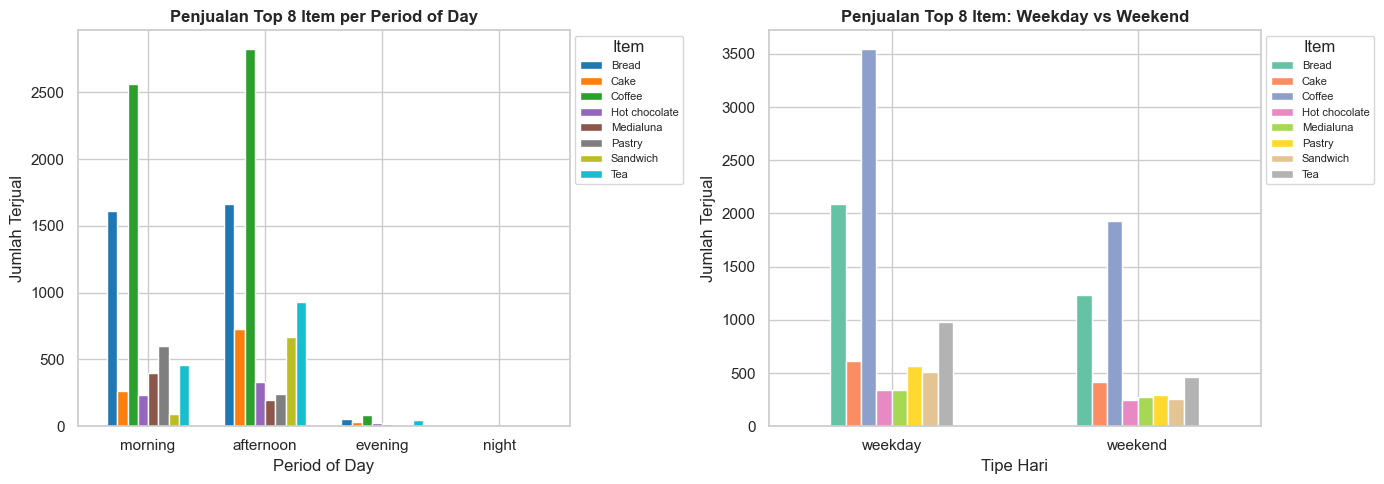

In [17]:
# 7. Analisis Konteks Temporal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 7a. Top 8 item per period_day
period_order = ['morning', 'afternoon', 'evening', 'night']
period_order = [p for p in period_order if p in df['period_day'].unique()]

top8 = df['Item'].value_counts().head(8).index
df_top8 = df[df['Item'].isin(top8)]

pivot_period = df_top8.groupby(['period_day', 'Item']).size().unstack(fill_value=0)
pivot_period = pivot_period.reindex([p for p in period_order if p in pivot_period.index])
pivot_period.plot(kind='bar', ax=axes[0], colormap='tab10', width=0.7)
axes[0].set_title('Penjualan Top 8 Item per Period of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Period of Day')
axes[0].set_ylabel('Jumlah Terjual')
axes[0].legend(title='Item', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# 7b. Top 8 item: Weekday vs Weekend
pivot_day = df_top8.groupby(['weekday_weekend', 'Item']).size().unstack(fill_value=0)
pivot_day.plot(kind='bar', ax=axes[1], colormap='Set2', width=0.5)
axes[1].set_title('Penjualan Top 8 Item: Weekday vs Weekend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipe Hari')
axes[1].set_ylabel('Jumlah Terjual')
axes[1].legend(title='Item', bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()